Original shape: (2483, 6)
Zero-volume rows: 71
Shape after removing zero-volume rows: (2412, 6)
Final shape after feature engineering & cleaning: (2392, 24)
Train size: 1913 Test size: 479

=== Random Forest (threshold = 0.5) ===
Accuracy: 0.5427974947807933
Confusion Matrix:
 [[234  27]
 [192  26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.90      0.68       261
           1       0.49      0.12      0.19       218

    accuracy                           0.54       479
   macro avg       0.52      0.51      0.44       479
weighted avg       0.52      0.54      0.46       479


Best RF threshold for Up class (by F1): 0.1

=== Random Forest (best threshold) ===
Accuracy: 0.4551148225469729
Confusion Matrix:
 [[  0 261]
 [  0 218]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       261
           1       0.46      1.00      0.63       218

    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



=== XGBoost (threshold = 0.5) ===
Accuracy: 0.5156576200417536
Confusion Matrix:
 [[207  54]
 [178  40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.79      0.64       261
           1       0.43      0.18      0.26       218

    accuracy                           0.52       479
   macro avg       0.48      0.49      0.45       479
weighted avg       0.49      0.52      0.47       479


Best XGBoost threshold for Up class (by F1): 0.1

=== XGBoost (best threshold) ===
Accuracy: 0.453027139874739
Confusion Matrix:
 [[  2 259]
 [  3 215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.01      0.02       261
           1       0.45      0.99      0.62       218

    accuracy                           0.45       479
   macro avg       0.43      0.50      0.32       479
weighted avg       0.42      0.45      0.29       479



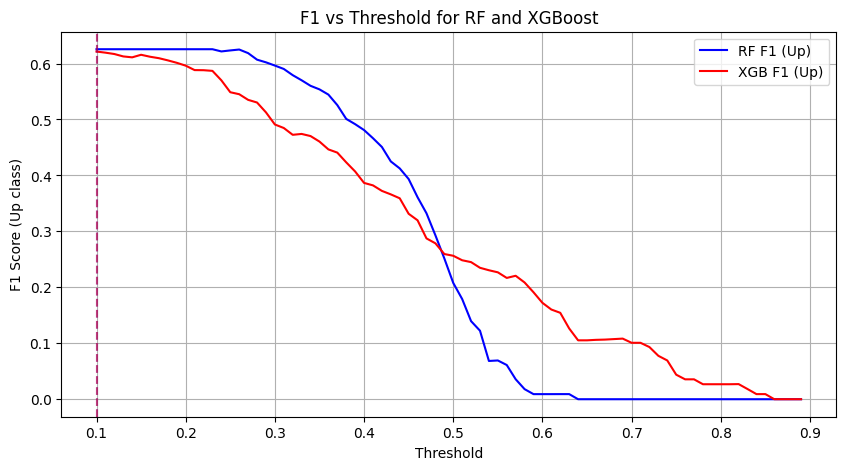

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

import xgboost as xgb

# =========================
# 1. Load & clean data
# =========================
df = pd.read_csv("Bank_Stock_Price_10Y.csv", parse_dates=['Date'], index_col='Date')

print("Original shape:", df.shape)

# Remove suspicious zero-volume rows (all OHLC equal, volume = 0)
zero_vol = df[df['Volume'] == 0]
print("Zero-volume rows:", len(zero_vol))

df = df[df['Volume'] != 0]
print("Shape after removing zero-volume rows:", df.shape)

# =========================
# 2. Basic return feature
# =========================
df['Daily_Return'] = df['Adj Close'].pct_change() * 100

# Drop first row (NaN Daily_Return)
df = df.dropna()

# =========================
# 3. Feature engineering
# =========================

# --- Price-based features ---
df['MA5'] = df['Adj Close'].rolling(5).mean()
df['MA10'] = df['Adj Close'].rolling(10).mean()
df['Return_1'] = df['Daily_Return'].shift(1)
df['Return_2'] = df['Daily_Return'].shift(2)
df['Return_3'] = df['Daily_Return'].shift(3)

# --- Volatility ---
df['Volatility_5'] = df['Daily_Return'].rolling(5).std()
df['Volatility_10'] = df['Daily_Return'].rolling(10).std()

# --- RSI (14) ---
delta = df['Adj Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df['Adj Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Adj Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# --- Bollinger Bands (20) ---
df['BB_Mid'] = df['Adj Close'].rolling(20).mean()
rolling_std = df['Adj Close'].rolling(20).std()
df['BB_Upper'] = df['BB_Mid'] + 2 * rolling_std
df['BB_Lower'] = df['BB_Mid'] - 2 * rolling_std

# --- Volume features ---
df['Volume_Change'] = df['Volume'].pct_change()
df['Volume_MA5'] = df['Volume'].rolling(5).mean()
df['Volume_MA10'] = df['Volume'].rolling(10).mean()

# =========================
# 4. Target variable
# =========================
df['Target'] = (df['Daily_Return'].shift(-1) > 0).astype(int)

# =========================
# 5. Clean NaNs / inf
# =========================
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("Final shape after feature engineering & cleaning:", df.shape)

# =========================
# 6. Feature list & split
# =========================
features = [
    'MA5','MA10','Return_1','Return_2','Return_3',
    'Volatility_5','Volatility_10','RSI','MACD','MACD_Signal',
    'BB_Upper','BB_Lower','Volume_Change','Volume_MA5','Volume_MA10'
]

X = df[features]
y = df['Target']

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train size:", len(X_train), "Test size:", len(X_test))

# =========================
# 7. Random Forest model
# =========================
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Default threshold (0.5)
y_pred_rf_default = rf_model.predict(X_test)
print("\n=== Random Forest (threshold = 0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_default))
print("Classification Report:\n", classification_report(y_test, y_pred_rf_default))

# Probability predictions
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Threshold tuning for Up class (maximize F1 for class 1)
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba_rf > t).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]

print("\nBest RF threshold for Up class (by F1):", best_threshold_rf)

y_pred_rf_best = (y_proba_rf > best_threshold_rf).astype(int)
print("\n=== Random Forest (best threshold) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_best))
print("Classification Report:\n", classification_report(y_test, y_pred_rf_best))

# =========================
# 8. XGBoost model
# =========================
# Convert to DMatrix (optional but common)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.05,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

num_round = 300
xgb_model = xgb.train(params, dtrain, num_boost_round=num_round)

# Predict probabilities
y_proba_xgb = xgb_model.predict(dtest)

# Default threshold 0.5
y_pred_xgb_default = (y_proba_xgb > 0.5).astype(int)

print("\n=== XGBoost (threshold = 0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_default))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_default))

# Threshold tuning for XGBoost
thresholds_xgb = np.arange(0.1, 0.9, 0.01)
f1_scores_xgb = []

for t in thresholds_xgb:
    y_pred_t = (y_proba_xgb > t).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    f1_scores_xgb.append(f1)

best_idx_xgb = np.argmax(f1_scores_xgb)
best_threshold_xgb = thresholds_xgb[best_idx_xgb]

print("\nBest XGBoost threshold for Up class (by F1):", best_threshold_xgb)

y_pred_xgb_best = (y_proba_xgb > best_threshold_xgb).astype(int)
print("\n=== XGBoost (best threshold) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_best))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_best))

# =========================
# 9. Optional: Plot F1 vs threshold
# =========================
plt.figure(figsize=(10,5))
plt.plot(thresholds, f1_scores, label='RF F1 (Up)', color='blue')
plt.plot(thresholds_xgb, f1_scores_xgb, label='XGB F1 (Up)', color='red')
plt.axvline(best_threshold_rf, color='blue', linestyle='--', alpha=0.5)
plt.axvline(best_threshold_xgb, color='red', linestyle='--', alpha=0.5)
plt.xlabel("Threshold")
plt.ylabel("F1 Score (Up class)")
plt.title("F1 vs Threshold for RF and XGBoost")
plt.legend()
plt.grid(True)
plt.show()